<a href="https://colab.research.google.com/github/vituhaa/Healthy-Posture/blob/project/keras_openpose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Код для получения фотографий из видео (использовался локально):

In [13]:
import os
import cv2
import json
import seaborn as sns
from matplotlib import pyplot as plt
from PIL import Image
from pathlib import Path

import numpy as np
import tensorflow as tf

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, Rescaling
from pycocotools.cocoeval import COCOeval
from pycocotools.coco import COCO

In [ ]:
import cv2, os

video_julia = 'julia_speed_4x.mp4'
video_sona = 'sona_4x.mp4'
video_me_d = 'me_dark_speed_4x.mp4'
video_me_l = 'me_light_speed_4x.mp4'
video_ilya_l = 'ilya_light_4x.mp4'
video_ilya_d = 'ilya_dark_speed_4x.mp4'
video_daniil = 'daniil_speed_4x.mp4'
video_mama = 'mama_speed_4x.mp4'
video_papa = 'papa_speed_2x.mp4'
video_kate = 'kate_2x.mp4'
video_me_new = 'me_new_speed_4x.mp4'
video_anya = 'anya_speed_4x.mp4'
video_nikita = 'nikita_speed_4x.mp4'
video_me1_l = 'me1_light_speed_2x.mp4'
video_me1_d = 'me1_dark_speed_2x.mp4'
video_una = 'una_speed_2x.mp4'
video_una_l = 'una_l_2x.mp4'
video_nikita_l = 'nikita_l_2x.mp4'
video_sona_1 = 'sona_1_2x.mp4'
video_sona_2 = 'sona_2_2x.mp4'
video_me = 'me_4x.mp4'
video_masha = 'masha_speed_4x.mp4'
video_nikita_sh = 'nikita_sh_speed_2x.mp4'
video_anya_2 = 'anya2_speed_4x.mp4'
video_me_rl = 'me_right_left_speed_1.5x.mp4'
video_me_right = 'me_right_speed_1.5x.mp4'
video_me_test1 = 'me_TEST1_speed_2x.mp4'
video_me_test2 = 'me_TEST2_speed_2x.mp4'
video_sona_correct = 'sona_correct_speed_2x.mp4'
video_me_correct = 'me_correct_speed_2x.mp4'
video_mama_correct = 'mama_correct_speed_2x.mp4'
video_nikita_correct = 'nikita_correct_speed_2x.mp4'
video_danya_correct = 'danya_correct_speed_4x.mp4'
video_ulya_correct = 'ulya_correct_speed_4x.mp4'
video_me1_correct = 'me_correct1_speed_2x.mp4'
video_kirill_correct = 'kirill_correct_speed_2x.mp4'
video_nikita_sh_correct = 'nikitash_correct_speed_2x.mp4'
video_vitya_correct = 'vitya_correct_speed_2x.mp4'
video_me3_correct = 'me3_correct_speed_4x.mp4'
video_me2_correct = 'me2_correct_speed_4x.mp4'
video_ilya_correct = 'ilya_correct_speed_4x.mp4'
video_kate_correct = 'kate_correct_speed_4x.mp4'
video_me4_correct = 'me_correct4_speed-4x.mp4'
video_mama2_correct = 'video_mama2_correct_cpeed_4x.mp4'
video_test = 'video_test_speed_4x.mp4'

video_arr = []
video_arr.append(video_daniil)
video_arr.append(video_julia)
video_arr.append(video_sona)
video_arr.append(video_me_d)
video_arr.append(video_me_l)
video_arr.append(video_ilya_l)
video_arr.append(video_ilya_d)
video_arr.append(video_kate)
video_arr.append(video_me_new)
video_arr.append(video_nikita)
video_arr.append(video_mama)
video_arr.append(video_me1_l)
video_arr.append(video_me1_d)
video_arr.append(video_papa)
video_arr.append(video_anya)
video_arr.append(video_una)
video_arr.append(video_una_l)
video_arr.append(video_nikita_l)
video_arr.append(video_sona_1)
video_arr.append(video_sona_2)
video_arr.append(video_me)
video_arr.append(video_masha)
video_arr.append(video_nikita_sh)
video_arr.append(video_anya_2)
video_arr.append(video_me_rl)
video_arr.append(video_me_right)
video_arr.append(video_me_test1)
video_arr.append(video_me_test2)
video_arr.append(video_sona_correct)
video_arr.append(video_me_correct)
video_arr.append(video_mama_correct)
video_arr.append(video_danya_correct)
video_arr.append(video_ulya_correct)
video_arr.append(video_me1_correct)
video_arr.append(video_kirill_correct)
video_arr.append(video_nikita_sh_correct)
video_arr.append(video_nikita_correct)
video_arr.append(video_vitya_correct)
video_arr.append(video_me2_correct)
video_arr.append(video_me3_correct)
video_arr.append(video_ilya_correct)
video_arr.append(video_kate_correct)
video_arr.append(video_me4_correct)
video_arr.append(video_mama2_correct)
video_arr.append(video_test)

output_folder = 'output'

for x in video_arr:
    cap = cv2.VideoCapture(x)
    if not cap.isOpened():
        print(f"видео {x} не открылось")
        exit(0)
    else:
        frames = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_number = f"frame_{frames:04d}.jpg"
            cv2.imwrite(os.path.join(output_folder, frame_number), frame)
            frames += 1

    cap.release()

print("видео разделены")

Проверка ресурсов nvidia для дальнейшего использования в работе с OpenPose

In [ ]:
! nvcc --version
! nvidia-smi

Скачиваю необходимые зависимости для OpenPose

In [ ]:
! sudo apt-get --assume-yes update
! sudo apt-get --assume-yes install build-essential
! sudo apt-get --assume-yes install libopencv-dev
! sudo apt-get --assume-yes install libatlas-base-dev libprotobuf-dev libleveldb-dev libsnappy-dev libhdf5-serial-dev protobuf-compiler
! sudo apt-get --assume-yes install --no-install-recommends libboost-all-dev
! sudo apt-get --assume-yes install libgflags-dev libgoogle-glog-dev liblmdb-dev
! sudo apt-get --assume-yes install python3-setuptools python3-dev build-essential
! sudo apt-get --assume-yes install python3-pip
! sudo -H pip3 install --upgrade numpy protobuf opencv-python
! sudo apt-get --assume-yes install opencl-headers ocl-icd-opencl-dev
! sudo apt-get --assume-yes install libviennacl-dev

Перехожу в рабочую папку и клонирую репозиторий OpenPose

In [ ]:
%%bash
cd /content
git clone https://github.com/CMU-Perceptual-Computing-Lab/openpose
cd openpose && git submodule update --init --recursive --remote

Скачиваю веса модели COCO (https://huggingface.co/camenduru/openpose/tree/main/models/pose/coco), так как их нет в папке с моделью

In [ ]:
%%bash
ls -lah /content/openpose/models/pose/coco/

Провожу операцию cmake внутри папки build, указывая флаги того, что нужно использовать

In [ ]:
%%bash
cd /content/openpose
rm -rf build
mkdir build
cd build
cmake .. \
  -DBUILD_PYTHON=OFF \
  -DBUILD_EXAMPLES=ON \
  -DGPU_MODE=CUDA \
  -DUSE_CUDNN=OFF

make -j"$(nproc)"

Создаю директорию output, чтобы провести инференс модели на фото, которые находятся внутри папки examples/media. В output складываются фотографии с размеченными скелетами и .json файлы с аннотяциями. Инференс выполняется с моделью COCO.

In [ ]:
%%bash
cd /content/openpose/
# mkdir output

./build/examples/openpose/openpose.bin \
  --image_dir examples/media/ \
  --write_images output/ \
  --write_json output/ \
  --display 0 \
  --disable_blending \
  --render_pose 1 \
  --model_pose COCO

ls -lah /content/openpose/output

Вывод фото в ноутбук

In [ ]:
res = Image.open('/content/openpose/output/COCO_val2014_000000000589_rendered.png')
plt.figure(figsize=(8, 8))
plt.imshow(res)
plt.show()

Инференс модели OpenPose прошёл успешно на базовых фотографиях, заложенных в репозитории. Проведём подобный эксперимент на 80 фотографиях сидячих людей и оценим результаты визуально.

In [ ]:
%%bash
cd /content/openpose/
# mkdir output

./build/examples/openpose/openpose.bin \
  --image_dir examples/media/custom_sitting_dataset \
  --write_images output/sitting_output_images/ \
  --write_json output/sitting_output_jsons/ \
  --display 0 \
  --render_pose 1 \
  --model_pose COCO

ls -lah /content/openpose/output

In [ ]:
rendered_photos = Path("/content/openpose/output/sitting_output_images")
for img in rendered_photos.rglob("*frame*"):
  if img in rendered_photos.rglob("*png*"):
    res = Image.open(img)
    plt.figure(figsize=(8, 8))
    plt.imshow(res)
    plt.show()

Визуально модель хорошо справляется с определением ключевых точек на теле сидячего человека. Тем не менее, заметно, что некоторые точки не определяются верно или не определяются вовсе. Сделаем вывод на основе метрик качества.

## Покажем качество модели на фото сидячих людей.

Попробуем обработать файлы с помощью инструмента COCOeval из библиотеки pycocotools. Для этого нужно скачать все .json файлы, которые создала модель для 80 фотографий, объединить в один и сравнить с одним файлом .json в COCO-формате, в котором находится рукотворная разметка фотографий, созданная в приложении Label Studio.

Фотографии были экспортированы в гугл колаб в том же порядке, в котором были обработаны в Label Studio.
Основная проблема инструмента COCOeval заключается в том, что на вход принимаются .json файлы с одинаковым количеством ключевых точек, в то время как OpenPose с флагом write_coco_json (COCO-формат) создаёт только 17 точек без шеи. Поэтому использовался флаг write_json, создающий 18 точек.

Пример по json файлу одной фотографии, который сгенерировал OpenPose.

In [11]:
arr = [507.973,331.592,0.754169,590.213,599.955,0.321802,351.16,619.557,
       0.272292,0,0,0,0,0,0,725.361,490.289,0.0630654,0,0,0,0,0,0,0,0,0,
       0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,462.945,321.814,0.864411,541.177,292.46,
       0.788628,431.463,384.494,0.435692,615.68,304.188,0.680305]
print(len(arr) / 3)

18.0


Соединим json файлы в один:

In [ ]:
def check_number_of_files(path):
  files_dir = os.listdir(path)
  k = 0
  for curr_file in files_dir:
    k += 1
  print(k)

print("JSON-файлов получилось: ")
check_number_of_files('/content/openpose/output/sitting_output_jsons')

print("Обработанных фото получилось: ")
check_number_of_files('/content/openpose/output/sitting_output_images')

In [23]:
# прохожусь по всем json файлам и мёрджу
def merge_jsons(json_files, output_file):
  files = os.listdir(json_files)
  out = sorted(files)
  arr_jsons = []
  merged_jsons = []
  # print(out)
  data = []
  for x in out:
    if 'json' in x:
      arr_jsons.append(x)
  for x in arr_jsons:
    with open(json_files + '/' + x, 'r', encoding='utf-8') as in_file:
      info = json.load(in_file)
      data.append(info)
  with open(output_file, 'w', encoding='utf-8') as out_file:
      json.dump(data, out_file, indent=4)

merge_jsons('/content/openpose/output/sitting_output_jsons', 'openpose_result.json')

В процессе работы возникла проблема с количеством "pose_keypoints_2d" в выходном файле JSON, в котором объеденены другие файлы JSON 80-ти фотографий: их получилось больше, чем предполагалось.

In [ ]:
def find_param_in_json(find, input_file):
  find_list = []
  find_list.append(find)
  count = 0
  with open(input_file, "r", encoding="utf-8") as in_file:
    info = json.load(in_file)

  stack = [info]
  while stack:
    x = stack.pop()
    if isinstance(x, dict):
      for k in find_list:
        if k in x:
          count += 1
      stack.extend(x.values())
    elif isinstance(x, list):
      stack.extend(x)
  return count

print("Количество keypoints в файле result_TRUE80.json: ")
find_param_in_json("keypoints", "result_TRUE80.json")

In [ ]:
print("Количество pose_keypoints_2d в файле openpose_result.json: ")
find_param_in_json("pose_keypoints_2d", "openpose_result.json")

В файле разметки из Label Studio лишний "keypoints" появился из-за того, что в начале файла есть объявление всех ключевых точек в проекте в целом, поэтому это можно не учитывать. Тем не менее, в JSON файле 7 лишних объявлений ключевых точек.

Файл был осмотрен вручную в сопоставлении с полученными фотографиями. Проблема обнаружена: OpenPose на некоторых фотографиях ложно определяет двух людей. В таком случае, для чистоты эксперимента, лишние столбцы "pose_keypoints_2d" были удалены вручную, файл записан как result_PRED80.json

Также при удалении лишних ключевых точек, опознанных как второй человек на фотографии, было замечено, что некоторые фотографии OpenPose вовсе не разметил, в таком случае принято решение оформить столбец с ключевыми точками в виде нулей.

In [ ]:
print("Количество pose_keypoints_2d в файле result_PRED80.json: ")
find_param_in_json("pose_keypoints_2d", "result_PRED80.json")

Как видно, теперь всё в порядке.

В статье https://www.pythontutorials.net/blog/coco-api-evaluation-for-subset-of-classes/ сказано, что формат predictions должен быть следующим:
1) image_id
2) category_id
3) bbox/keypoints/area
4) score

In [27]:
# отредактируем остальные части файла с помощью кода
res_file = [] # сюда будут записываться результаты изменённого файла
with open("result_PRED80.json", "r", encoding="utf-8") as in_file: # открываю файл, читаю
  info = json.load(in_file)
inner_count = 0
for x in info:
  for k in x.get("people"):
    inner_keypoints = k.get("pose_keypoints_2d") # список ключевых точек
    inner_image_id = k.get("image_id")
    category_id = 1 # всегда равна 1, так как в разметке из label studio ключевые точки лежат под категорией 1
    lst_confidence = inner_keypoints[2:len(inner_keypoints):3]
    for i in range (2, len(inner_keypoints), 3):
      if (inner_keypoints[i] != 0):
        inner_keypoints[i] = 2 # visibility
    sum_confidence = 0
    len_confidence = 0
    for i in range(len(lst_confidence)):
      if lst_confidence[i] != 0:
        sum_confidence += lst_confidence[i]
        len_confidence += 1
    if len_confidence == 0:
      score = 0
    else:
      score = sum_confidence / len_confidence # среднее по ненулевым confidence из списка ключевых точек
    # print(score)
    res_file.append({"image_id": inner_image_id, "category_id": category_id, "keypoints": inner_keypoints, "score": score})

with open('result_PRED80.json', 'w', encoding='utf-8') as out_file:
  json.dump(res_file, out_file, indent=4)

In [28]:
def check_ideal_annotations_file(anns_file_true):
  with open(anns_file_true, "r", encoding="utf-8") as in_file: # открываю файл, читаю
    info = json.load(in_file)
  arr = []
  for x in info.get("annotations"):
    arr.append(x.get("keypoints"))
  print("Количество фотографий:", len(arr))
  print("Количество ключевых точек для каждой фотографии:")
  for x in arr:
    print(len(x) / 3)

def check_pred_annotations(anns_file_pred):
  with open(anns_file_pred, "r", encoding="utf-8") as in_file: # открываю файл, читаю
    info = json.load(in_file)
  arr = []
  for x in info:
    # print(x)
    arr.append(x.get("keypoints"))
  print("Количество фотографий:", len(arr))
  print("Количество ключевых точек для каждой фотографии:")
  for x in arr:
    print(len(x) / 3)

In [ ]:
check_pred_annotations("result_PRED80.json")

Также отредактируем файл с показательной разметкой:

In [30]:
# id
# image_id
# category_id
# segmentation
# ignore
# iscrowd
# area
# keypoints
# num_keypoints
# bbox
def make_ideal_annotations_file(input_file, output_file):
  ideal_annotations = []
  with open(input_file, "r", encoding="utf-8") as in_file:
    info = json.load(in_file)
    arr_keypoints = []
    category_id = 1
    inner_segmentation = []
    ignore = 0
    iscrowd = 0
    inner_id = 0
    arr_num_keypoints = []
    for x in info.get("annotations"):
      for c in x:
        if c == "num_keypoints":
          i_num_keypoints = x.get("num_keypoints")
          arr_num_keypoints.append(i_num_keypoints)
    i = 0
    arr_bbox = []
    for x in info.get("annotations"):
      for c in x:
        if c == "bbox":
          j_arr_bbox = x.get("bbox")
          arr_bbox.append(j_arr_bbox)
    j = 0
    lst_bbox = arr_bbox[1:len(arr_bbox):2]
    for x in info.get("annotations"):
      # print(inner_area)
      for c in x:
        if c == "area":
          inner_area = x.get("area")
        if c == "keypoints":
          inner_keypoints = x.get("keypoints")
          ideal_annotations.append({"id": inner_id,
                                    "image_id": inner_id,
                                    "category_id": category_id,
                                    "segmentation": inner_segmentation,
                                    "ignore": ignore,
                                    "iscrowd": iscrowd,
                                    "area": inner_area,
                                    "keypoints": inner_keypoints,
                                    "num_keypoints": arr_num_keypoints[i],
                                    "bbox": lst_bbox[j]})
          inner_id += 1
          i += 1
          j += 1

    result_file_keys = ["images", "categories", "annotations", "info"]
    result_file = dict(zip(result_file_keys,[info.get("images"), info.get("categories"),
                                            ideal_annotations, info.get("info")]))

    with open(output_file, 'w', encoding='utf-8') as out_file:
      json.dump(result_file, out_file, indent=4)

In [31]:
make_ideal_annotations_file("result_TRUE80.json", "ideal_annotations80.json")

In [ ]:
check_ideal_annotations_file("ideal_annotations80.json")

То есть, размерности совпадают, но есть ошибка ValueError: operands could not be broadcast together with shapes (18,) (17,).

In [ ]:
ground_truth = COCO('/content/ideal_annotations80.json')
predictions = ground_truth.loadRes('/content/result_PRED80.json')

print(len(ground_truth.dataset['categories']))
print(len(predictions.dataset['categories']))

print(len(ground_truth.dataset['images']))
print(len(predictions.dataset['images']))

print(len(ground_truth.dataset['annotations']))
print(len(predictions.dataset['annotations']))

print((ground_truth.dataset['annotations']))
print((predictions.dataset['annotations']))

sigmas_original = np.array([0.026, 0.025, 0.025, 0.035, 0.035, 0.079, 0.079, 0.072, 0.072,
                   0.062, 0.062, 0.107, 0.107, 0.087, 0.087, 0.089, 0.089])
sigmas_edited = np.concatenate([sigmas_original, [0.05]])
print(sigmas_edited)
eval = COCOeval(ground_truth, predictions, "keypoints")
# print(eval.params.kpt_oks_sigmas) # [0.026 0.025 0.025 0.035 0.035 0.079 0.079 0.072 0.072 0.062 0.062 0.107 0.107 0.087 0.087 0.089 0.089]
eval.params.kpt_oks_sigmas = sigmas_edited
eval.evaluate()
eval.accumulate()
eval.summarize()

## Попытаемся дообучить модель OpenPose на датасете сидячих людей, чтобы модель лучше предсказывала нахождение ключевых точек на теле людей и сделаем вывод.

In [ ]:
%%bash
cd /content/
mkdir fine-tuning-dataset
cd fine-tuning-dataset/ # здесь лежит датасет на дообучение

cd /content/openpose/examples/media/custom_sitting_dataset # здесь лежит датасет на проверку

In [ ]:
prototxt_path = '/content/openpose/models/pose/coco/pose_deploy_linevec.prototxt'
prototxt_file = open(prototxt_path, 'r')
inside = prototxt_file.read()
print(inside)
prototxt_file.close()

In [ ]:
find_word = 'layer'
k = 0
with open(prototxt_path, 'r') as prototxt_file:
  lines = prototxt_file.readlines()
  for x in lines:
    if x.find(find_word) != -1:
      k += 1
print("Layers = ", k)

https://graphics.cs.cmu.edu/courses/16-824/2016_spring/slides/caffe_tutorial.pdf

https://topic.alibabacloud.com/a/caffe-easy-to-use-guide-iii-using-models-for-fine-tune_8_8_31236460.html

In [ ]:
# создание файлов /content/openpose/examples/fine_tune/data/train.txt и
# /content/openpose/examples/fine_tune/data/test.txt
import json, os

def make_txt_train_test(input_txt, input_anns, photo_paths):
  dataset_photos = sorted(os.listdir(photo_paths))
  arr_keypoints = []
  # читаем точки из файла аннотаций
  with open(input_anns, "r", encoding="utf-8") as anns:
    info = json.load(anns)
    for x in info.get("annotations"):
      for c in x:
        if c == "keypoints":
          inner_keypoints = x.get("keypoints")
          arr_keypoints.append(inner_keypoints)
  print(dataset_photos)
  # создаём текстовый файл
  with open(input_txt, "w") as file_txt:
    for i in range(len(dataset_photos)):
      file_txt.write(str(dataset_photos[i]) + " " + str(arr_keypoints[i]) + f"\n")
  file_txt.close()

result_true150 = '/content/result_TRUE150.json'
ideal_annotations150 = '/content/ideal_annotations150.json'
make_ideal_annotations_file(result_true150, ideal_annotations150)

In [ ]:
train = '/content/train.txt'
fine_tuning_dataset_path = '/content/drive/MyDrive/fine_tuning_dataset'
make_txt_train_test(train, ideal_annotations150, fine_tuning_dataset_path)

In [ ]:
test = '/content/test.txt'
val_dataset_path = '/content/drive/MyDrive/sitting_pose_dataset'
make_txt_train_test(test, '/content/ideal_annotations80.json', val_dataset_path)

In [ ]:
! ls

drive			   openpose		 result_TRUE150.json  test.txt
ideal_annotations150.json  openpose_result.json  result_TRUE80.json   train.txt
ideal_annotations80.json   result_PRED80.json	 sample_data


In [ ]:
import torch
import torch.nn as nn
import cv2
import torch.optim as optim
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.io import decode_image

prototxt_path = '/content/openpose/models/pose/coco/pose_deploy_linevec.prototxt'
caffe_path = '/content/openpose/models/pose/coco/pose_iter_440000.caffemodel'
result_true150 = '/content/drive/MyDrive/result_TRUE150.json'
finetune_coco_path = '/content/openpose/models/pose/coco/finetune_coco.prototxt'

# создаю finetune_coco.prototxt как train_val
# копирую содержимое из pose_deploy_linevec.prototxt (в finetune_coco.prototxt он похожий)
prototxt_file = open(prototxt_path, 'r')
inside = prototxt_file.read()
prototxt_file.close()
finetune_coco_file = open(finetune_coco_path, 'w')
finetune_coco_file.write(inside)
finetune_coco_file.close()
# теперь добавляю в начало train и test пути
# source нужно поменять на свой
with open(finetune_coco_path, 'r+') as finetune_coco:
  inside_content = finetune_coco.read()
  finetune_coco.seek(0, 0)
  finetune_coco.write('name: "FineTunedOpenPose\n')
  finetune_coco.write('layer {\n')
  finetune_coco.write('  name: "data"\n')
  finetune_coco.write('  type: "FineTuningData"\n')
  finetune_coco.write('  top: "data"\n')
  finetune_coco.write('  top: "label"\n')
  finetune_coco.write('  include {\n')
  finetune_coco.write('    phase: TRAIN\n')
  finetune_coco.write('  }\n')
  finetune_coco.write('  finetune_data_param {\n')
  finetune_coco.write('    source: "/content/train.txt"\n')
  finetune_coco.write('    batch_size: 10\n')
  finetune_coco.write('  }\n')
  finetune_coco.write('}\n')
  finetune_coco.write('layer {\n')
  finetune_coco.write('  name: "data"\n')
  finetune_coco.write('  type: "FineTuningData"\n')
  finetune_coco.write('  top: "data"\n')
  finetune_coco.write('  top: "label"\n')
  finetune_coco.write('  include {\n')
  finetune_coco.write('    phase: TEST\n')
  finetune_coco.write('  }\n')
  finetune_coco.write('  finetune_data_param {\n')
  finetune_coco.write('    source: "/content/test.txt"\n')
  finetune_coco.write('    batch_size: 10\n')
  finetune_coco.write('  }\n')
  finetune_coco.write('}\n')
  finetune_coco.write(inside_content)
finetune_coco.close()

with open(finetune_coco_path, 'a') as finetune_coco:
  # inside_content = finetune_coco.read()
  # finetune_coco.write(inside_content)
  finetune_coco.write('layer {\n')
  finetune_coco.write('  name: "loss"\n')
  finetune_coco.write('  type: "SoftmaxWithLoss"\n')
  finetune_coco.write('  bottom: "concat_stage7"\n')
  finetune_coco.write('  bottom: "label"\n')
  finetune_coco.write('  top: "loss"\n')
  finetune_coco.write('}\n')
  finetune_coco.write('layer {\n')
  finetune_coco.write('  name: "accuracy"\n')
  finetune_coco.write('  type: "Accuracy"\n')
  finetune_coco.write('  bottom: "concat_stage7"\n')
  finetune_coco.write('  bottom: "label"\n')
  finetune_coco.write('  top: "accuracy"\n')
  finetune_coco.write('  include {\n')
  finetune_coco.write('    phase: TEST\n')
  finetune_coco.write('  }\n')
  finetune_coco.write('}')
finetune_coco.close()


# создаю файл solver.prototxt в папке COCO:
solver_prototxt_path = '/content/openpose/models/pose/coco/solver.prototxt'
with open(solver_prototxt_path, "w") as solver_prototxt:
  # + net: "coco/finetune_coco.prototxt"
  solver_prototxt.write('net: "/content/openpose/models/pose/coco/finetune_coco.prototxt"\n')
  solver_prototxt.write('test_iter: 10\n')
  solver_prototxt.write('test_interval: 1000\n')
  solver_prototxt.write('base_lr: 0.01\n')
  solver_prototxt.write('momentum: 0.9\n')
  solver_prototxt.write('weight_decay: 0.004\n')
  solver_prototxt.write('lr_policy: "step"\n')
  solver_prototxt.write('gamma: 0.1\n')
  solver_prototxt.write('stepsize: 100000\n')
  solver_prototxt.write('display: 100\n')
  solver_prototxt.write('max_iter: 350000\n')
  solver_prototxt.write('snapshot: 10000\n')
  solver_prototxt.write('snapshot_prefix: "/content/snapshots"')
  solver_prototxt.write('solver_mode: GPU')

solver_prototxt.close()

Работаем с caffe:

In [ ]:
!sudo apt-get install libhdf5-serial-dev hdf5-tools

In [ ]:
%cd /content/openpose/3rdparty/caffe
! cp Makefile.config.Ubuntu14_cuda7.example Makefile.config
# дальше редактируем файл
! sed -i 's/# OPENCV_VERSION := 3/OPENCV_VERSION := 3/' Makefile.config
! sed -i 's/-gencode arch=compute_30,code=sm_30/-gencode arch=compute_75,code=sm_75/' Makefile.config
! sed -i '\|-gencode arch=compute_35,code=sm_35|d' Makefile.config
! sed -i '\|-gencode arch=compute_50,code=sm_50|d' Makefile.config
! sed -i '\|-gencode arch=compute_52,code=sm_52|d' Makefile.config
! sed -i 's|^PYTHON_INCLUDE := .*|PYTHON_INCLUDE := /usr/include/python3.10 \ /usr/lib/python3.10/dist-packages/numpy/core/include|' Makefile.config
! sed -i '\|usr/lib/python2.7/dist-packages/numpy/core/include|d' Makefile.config
# ! sed -i 's| /usr/lib/python2.7/dist-packages/numpy/core/include| /usr/lib/python3.10/dist-packages/numpy/core/include|' Makefile.config
! sed -i 's|^INCLUDE_DIRS := .*|INCLUDE_DIRS := $(PYTHON_INCLUDE) /usr/local/include /usr/include/opencv4 /usr/include/hdf5/serial/|' Makefile.config
# ! sed -i 's|^LIBRARY_DIRS := .*|LIBRARY_DIRS := $(PYTHON_LIB) /usr/local/lib /usr/lib'

/content/openpose/3rdparty/caffe


In [ ]:
! sed -i 's/CV_LOAD_IMAGE_COLOR/IMREAD_COLOR/g' src/caffe/layers/window_data_layer.cpp

In [ ]:
!make clean
!make all -j$(nproc)

Провести дообучение с помощью фреймворка caffe не удалось.

## Создание нейронной сети:

In [ ]:
# создаю датасет для классификатора, операцию провожу 1 раз
%%bash
cd /content/openpose/

./build/examples/openpose/openpose.bin \
  --image_dir "/content/drive/MyDrive/datasets_for_3course/EfficientNetB0_dataset/bad" \
  --write_images "/content/drive/MyDrive/datasets_for_3course/OpenPose_dataset/train_rendered/bad" \
  --write_json "/content/drive/MyDrive/datasets_for_3course/OpenPose_dataset/jsons_bad_train" \
  --display 0 \
  --disable_blending \
  --render_pose 1 \
  --model_pose COCO

./build/examples/openpose/openpose.bin \
  --image_dir "/content/drive/MyDrive/datasets_for_3course/EfficientNetB0_dataset/good" \
  --write_images "/content/drive/MyDrive/datasets_for_3course/OpenPose_dataset/train_rendered/good" \
  --write_json "/content/drive/MyDrive/datasets_for_3course/OpenPose_dataset/jsons_good_train" \
  --display 0 \
  --disable_blending \
  --render_pose 1 \
  --model_pose COCO

./build/examples/openpose/openpose.bin \
  --image_dir "/content/drive/MyDrive/datasets_for_3course/EfficientNetB0_Test/bad" \
  --write_images "/content/drive/MyDrive/datasets_for_3course/OpenPose_dataset/test_rendered/bad" \
  --write_json "/content/drive/MyDrive/datasets_for_3course/OpenPose_dataset/jsons_bad_test" \
  --display 0 \
  --disable_blending \
  --render_pose 1 \
  --model_pose COCO

./build/examples/openpose/openpose.bin \
  --image_dir "/content/drive/MyDrive/datasets_for_3course/EfficientNetB0_Test/good" \
  --write_images "/content/drive/MyDrive/datasets_for_3course/OpenPose_dataset/test_rendered/good" \
  --write_json "/content/drive/MyDrive/datasets_for_3course/OpenPose_dataset/jsons_good_test" \
  --display 0 \
  --disable_blending \
  --render_pose 1 \
  --model_pose COCO

In [ ]:
! pip uninstall numpy -y
! pip install numpy==1.23.5

In [65]:
import numpy as np
print(np.__version__)
import tensorflow as tf

2.0.2


In [3]:
ds_dir = "/content/drive/MyDrive/datasets_for_3course/OpenPose_dataset/train_rendered/"
test_path = "/content/drive/MyDrive/datasets_for_3course/OpenPose_dataset/test_rendered/"

In [ ]:
# получаю предсказания от модели в папку с отрендеренными фотками (для трейна и теста)
# делаю фон чёрным у фотографий

# преобразование датасета:
# 1) определить точки с помощью openpose, фон сделать чёрным
# 2) обрезать фото до 60*60 пикселей
# 3) разметить на 0 и 1 - good и bad
# 4) аугментация
# 5) нормализация

In [79]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(64, 64),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(64, 64),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    batch_size=32,
    image_size=(64, 64),
    shuffle=False
)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2)
])

filter_size = (3, 3)

# архитектура vgg19 + аугментация
model = Sequential([
    Rescaling(1./255, input_shape=(64, 64, 3)),
    augmentation,
    Conv2D(64, filter_size, activation='relu', padding='same'),
    Conv2D(64, filter_size, activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(128, filter_size, activation='relu', padding='same'),
    Conv2D(128, filter_size, activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(256, filter_size, activation='relu', padding='same'),
    Conv2D(256, filter_size, activation='relu', padding='same'),
    Conv2D(256, filter_size, activation='relu', padding='same'),
    Conv2D(256, filter_size, activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(512, filter_size, activation='relu', padding='same'),
    Conv2D(512, filter_size, activation='relu', padding='same'),
    Conv2D(512, filter_size, activation='relu', padding='same'),
    Conv2D(512, filter_size, activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(512, filter_size, activation='relu', padding='same'),
    Conv2D(512, filter_size, activation='relu', padding='same'),
    Conv2D(512, filter_size, activation='relu', padding='same'),
    Conv2D(512, filter_size, activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(4096, activation='relu'),
    Dense(4096, activation='relu'),
    # output:
    Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=["accuracy"]
)

Found 3099 files belonging to 2 classes.
Using 2480 files for training.
Found 3099 files belonging to 2 classes.
Using 619 files for validation.
Found 60 files belonging to 2 classes.


In [ ]:
model.summary()

In [ ]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

model.save('openpose_classifier_model.h5')

In [ ]:
! pip install --upgrade scikit-learn

In [ ]:
model = tf.keras.models.load_model('openpose_classifier_model.h5')
true_categories = []
pred_categories = []
for classes in os.listdir(test_path):
  class_path = test_path + '/' + classes
  for photo in os.listdir(class_path):
    photo_path = test_path + '/' + classes + '/' + photo
    true_categories.append(classes)
    img = cv2.imread(photo_path)
    img = cv2.resize(img, (64, 64))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)[0][0]
    category = 0
    if prediction >= 0.5:
      category = 1
    else:
      category = 0
    pred_categories.append(category)

true_labels = []
for x in true_categories:
  if x == 'bad':
    true_labels.append(0)
  else:
    true_labels.append(1)

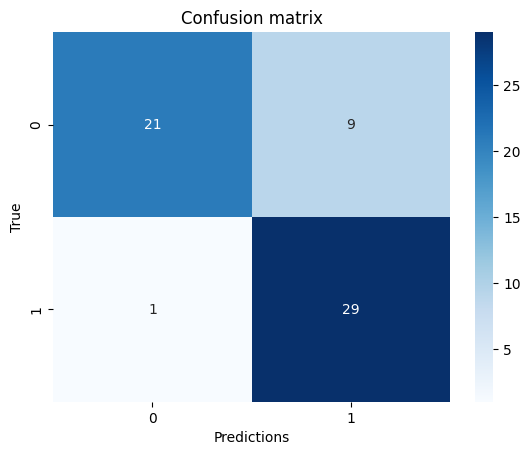

Metrics of OpenPose classifier: 

Accuracy:  0.8333333333333334
Precision:  0.9666666666666667
Recall:  0.7631578947368421


In [14]:
saved_model = tf.keras.models.load_model('openpose_classifier_model.h5')

matrix = confusion_matrix(true_labels, pred_categories)
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predictions')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

accuracy = accuracy_score(pred_categories, true_labels)
precision = precision_score(pred_categories, true_labels)
recall = recall_score(pred_categories, true_labels)
print("Metrics of OpenPose classifier: \n")
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)